In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#x= torch.randn(400).to(device)
#x=torch.sin(torch.linspace(0,4*np.pi,2000)).to(device)*10#+0.01*torch.randn(2000).to(device)
#data = x.detach().cpu().numpy()
data=10*np.sin(np.linspace(0, 10*np.pi, 400))+0.8*np.random.randn(400)
series = pd.Series(data)

t=300
train = series.iloc[:t+1]
model = ARIMA(train, order=(2, 0, 10))
result = model.fit()

print(series.index)

NameError: name 'ARIMAX' is not defined

In [ ]:
#test for stationarity
ADF_p = adfuller(data)
print('ADF Statistic:', ADF_p[0])
print('p-value:', ADF_p[1])

ADF Statistic: -9.985144507025772
p-value: 2.0649296451727052e-17


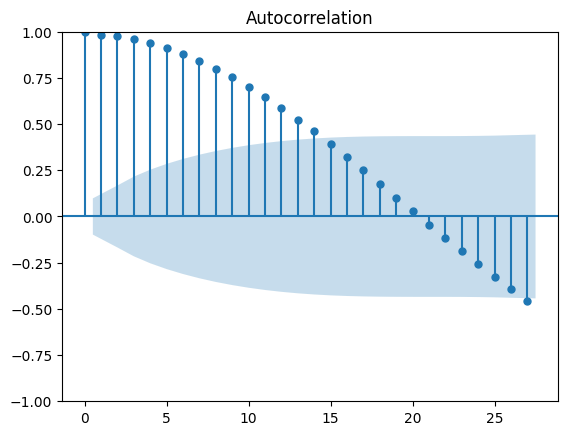

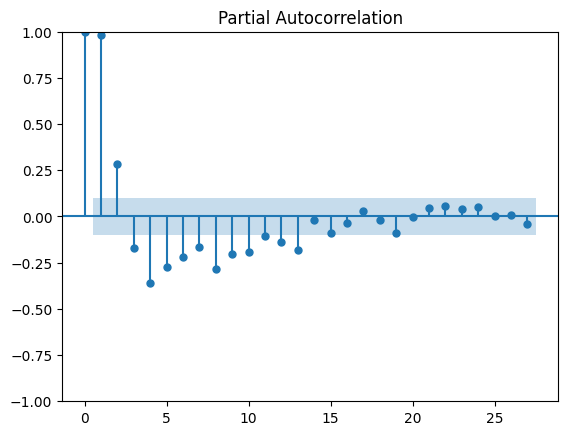

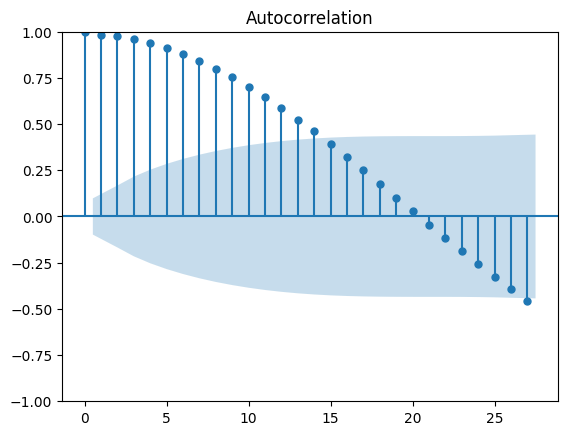

In [ ]:
plot_pacf(data)
plot_acf(data)

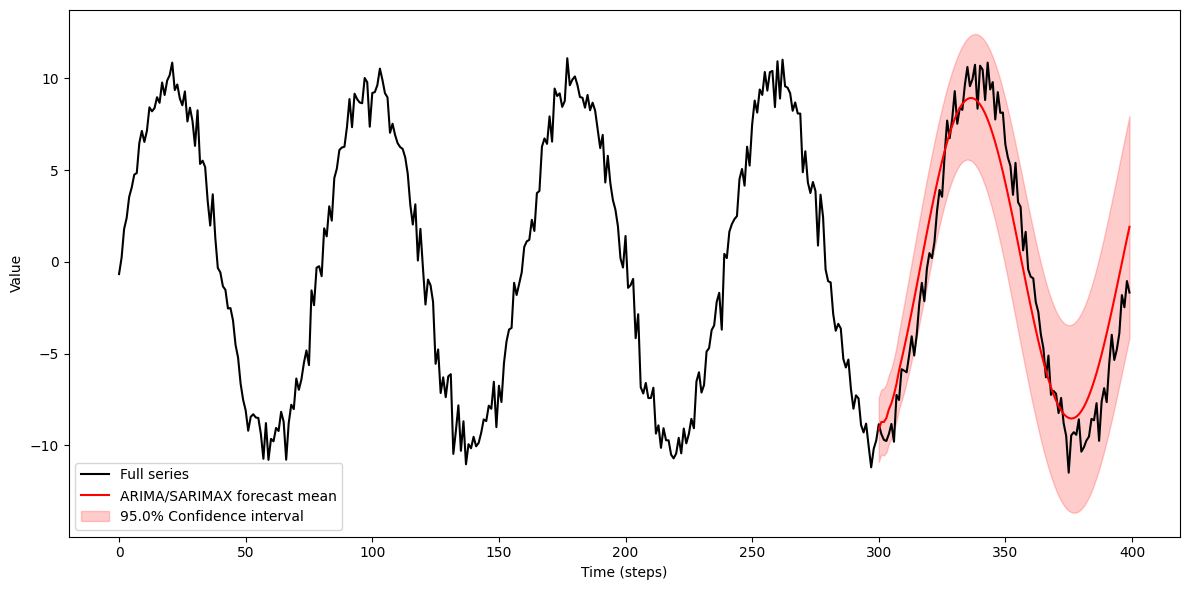

In [ ]:
steps = len(series) - t
n_sim=1

test = series.iloc[t:]
forecast_res = result.get_forecast(steps=steps)
ci = forecast_res.conf_int(alpha=0.05)
ci.index = test.index

print(result)

sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))
plt.plot(series.index, series, color="black", label="Full series")
#plt.plot(test.index, test, color="blue", label="Ground truth")

plt.plot(test.index, forecast_res.predicted_mean  , color="red", label="ARIMA/SARIMAX forecast mean")
#for sim in sims:
#    plt.plot(sim.index, sim, color="orange", alpha=0.5, label="Simulated path" if n_sim == 1 else None)

plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.2, label=f'{100*(1-0.05)}% Confidence interval')
plt.xlabel("Time (steps)")
plt.ylabel("Value")
#plt.title(f'ARIMA/SARIMAX Forecast, MAE:{MAE(series, t, forecast_res, steps=steps):.4f}, CRPS:{CRPS(result, test_values=test, steps=steps):.4f}')
plt.legend()
plt.tight_layout()
plt.show()